# SINGLE-CELL END-TO-END ABC PIPELINE — GSE161626

>>> Workspace: /content/ABC_DOI
>>> Downloading GSE161626 from FTP mirror (slow, ~20–40 min)…
    URL: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE161nnn/GSE161626/suppl/GSE161626_RAW.tar
>>> Valid tar: data/GSE161626_RAW.tar (7547.1 MB)
>>> Archive contains 80 members. First 15:
     GSM4911405_VEH1-1-K27ac.bw
     GSM4911406_VEH1-2-K27ac.bw
     GSM4911407_VEH2-1-K27ac.bw
     GSM4911408_VEH2-2-K27ac.bw
     GSM4911409_VEH3-1-K27ac.bw
     GSM4911410_VEH3-2-K27ac.bw
     GSM4911411_VEH4-1-K27ac.bw
     GSM4911412_VEH4-2-K27ac.bw
     GSM4911413_VEH5-1-K27ac.bw
     GSM4911414_VEH5-2-K27ac.bw
     GSM4911415_VEH6-1-K27ac.bw
     GSM4911416_VEH6-2-K27ac.bw
     GSM4911417_24h1-1-K27ac.bw
     GSM4911418_24h1-2-K27ac.bw
     GSM4911419_24h2-1-K27ac.bw
>>> K27ac bigWig members matched in tar: 48
>>> K27ac bigWigs on disk: 48
>>> Samples per group:
 {'24h': 12, '48h': 12, '7d': 12, 'VEH': 12}


Peak union:   0%|          | 0/24 [00:00<?, ?it/s]

>>> Consensus peaks: 68300


Quantify signal:   0%|          | 0/48 [00:00<?, ?it/s]

>>> Signal matrix: (68300, 48)
>>> Significant 7d-vs-VEH enhancers: 14438
>>> Cluster profiles:
           VEH   24h   48h    7d
cluster                        
0       -1.41  0.57  0.52  0.32
1        1.10  0.09 -0.02 -1.17
2       -0.28 -0.59 -0.52  1.39
3        0.30  0.61  0.50 -1.41
4        1.39 -0.52 -0.55 -0.31
5       -1.14 -0.09  0.12  1.12
>>> Persistent UP clusters [0, 5], DOWN [1, 4]; total persistent enhancers: 9889
>>> Protein-coding genes: 21674


ABC scoring:   0%|          | 0/21674 [00:00<?, ?it/s]

>>> ABC predictions above threshold: 471819
>>> Final enhancer-gene pairs: 471819 | unique target genes: 21516
>>> RNA TXT not found in TAR — skipped


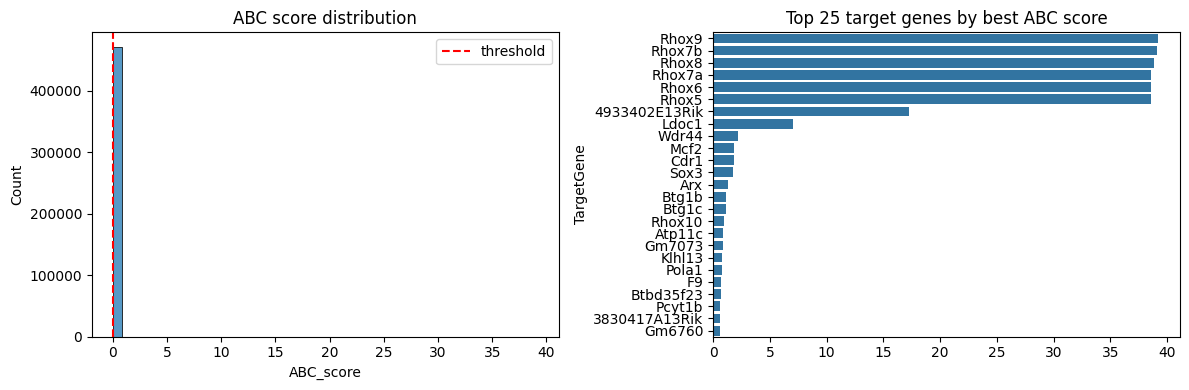

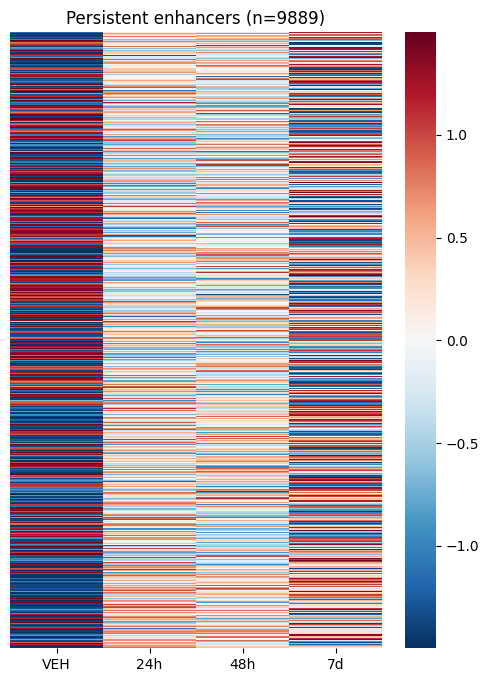


=== DONE ===
Outputs in: /content/ABC_DOI/ABC_output


CompletedProcess(args='ls -lh ABC_output/', returncode=0)

In [ ]:
# =====================================================================
# SINGLE-CELL END-TO-END ABC PIPELINE — GSE161626 (mouse H3K27ac)
# Persistent enhancers (VEH→24h→48h→7d) linked to genes via ABC model
# =====================================================================

# ---------- 0. Install deps ----------
import subprocess, sys
subprocess.run("pip -q install pyBigWig pyranges gtfparse statsmodels tqdm seaborn",
               shell=True, check=False)
subprocess.run("apt-get -qq install -y wget > /dev/null", shell=True, check=False)

import os, re, glob, warnings
import numpy as np, pandas as pd
import pyBigWig, pyranges as pr
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import quantile_transform
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

# ---------- 1. Workspace ----------
WORK = "/content/ABC_DOI"
os.makedirs(WORK, exist_ok=True); os.chdir(WORK)
for d in ["data/bw","data/rna","abc_inputs","peaks","ABC_output"]:
    os.makedirs(d, exist_ok=True)
print(">>> Workspace:", WORK)

# ---------- 2. Download GSE161626 bigWigs  (FIX: use FTP mirror, not reCAPTCHA URL) ----------
ACC  = "GSE161626"
STUB = ACC[:-3] + "nnn"                       # GSE161626 -> GSE161nnn
FTP_TAR = (f"https://ftp.ncbi.nlm.nih.gov/geo/series/{STUB}/{ACC}/"
           f"suppl/{ACC}_RAW.tar")
TAR = "data/GSE161626_RAW.tar"

def _looks_like_html(path):
    """The reCAPTCHA/interstitial page is HTML; a real RAW tar is not."""
    try:
        with open(path, "rb") as fh:
            head = fh.read(512).lower()
        return (b"<!doctype html" in head or b"<html" in head
                or b"checking your browser" in head)
    except FileNotFoundError:
        return True

def _valid_tar(path):
    if not os.path.exists(path) or os.path.getsize(path) < 10_000:
        return False
    if _looks_like_html(path):
        return False
    # tar -t must succeed on a real archive
    return subprocess.run(f"tar -tf {path} > /dev/null 2>&1",
                          shell=True).returncode == 0

if not _valid_tar(TAR):
    print(f">>> Downloading {ACC} from FTP mirror (slow, ~20–40 min)…")
    print("    URL:", FTP_TAR)
    subprocess.run(f'wget -q -O {TAR} "{FTP_TAR}"', shell=True, check=True)

# FAIL FAST with a clear message instead of a downstream KeyError
if _looks_like_html(TAR):
    raise RuntimeError(
        "Downloaded file is an HTML interstitial (reCAPTCHA 'Checking your "
        "browser') page, NOT the RAW tar. Do not use the /geo/download/ "
        "browser URL. Use the FTP mirror:\n  " + FTP_TAR)
if not _valid_tar(TAR):
    raise RuntimeError(f"{TAR} is not a valid tar archive "
                       f"(size={os.path.getsize(TAR)} bytes). Download failed.")
print(f">>> Valid tar: {TAR} ({os.path.getsize(TAR)/1e6:.1f} MB)")

# --- DEBUG: dump the archive listing so filename patterns are visible ---
listing = subprocess.run(f"tar -tf {TAR}", shell=True,
                         capture_output=True, text=True).stdout.splitlines()
print(f">>> Archive contains {len(listing)} members. First 15:")
for x in listing[:15]:
    print("    ", x)

# Match H3K27ac bigWigs, tolerating .bw / .bigWig and an optional .gz
subprocess.run(
    f"tar -tf {TAR} | grep -iE 'k27ac' "
    f"| grep -iE '\\.(bw|bigwig)(\\.gz)?$' > data/bw_list.txt",
    shell=True)
n_listed = sum(1 for _ in open("data/bw_list.txt"))
print(">>> K27ac bigWig members matched in tar:", n_listed)
if n_listed == 0:
    raise RuntimeError(
        "No H3K27ac bigWig members found in the archive. Inspect the listing "
        "printed above and adjust the grep pattern / sample regex accordingly.")

subprocess.run(f"tar -xf {TAR} -C data/bw/ -T data/bw_list.txt", shell=True)
# GEO sometimes gzips the bigWigs; decompress any *.gz in place
subprocess.run("gunzip -f data/bw/*.gz 2>/dev/null", shell=True)
bw_files = sorted(glob.glob("data/bw/**/*.bw", recursive=True) +
                  glob.glob("data/bw/**/*.bigWig", recursive=True))
print(">>> K27ac bigWigs on disk:", len(bw_files))

# ---------- 3. Sample sheet  (FIX: robust regex + guard) ----------
# Flexible pattern: <group><mouse>-<rep>-K27ac  e.g. VEH1-2-K27ac, 7d3-1-K27ac
SAMPLE_RE = re.compile(r"(VEH|24h|48h|7d)\s*(\d+)[-_](\d+)[-_].*?k27ac",
                       re.IGNORECASE)
rows = []
for f in bw_files:
    m = SAMPLE_RE.search(os.path.basename(f))
    if m:
        rows.append({"file": f, "group": m.group(1).upper() if m.group(1)=="veh"
                     else m.group(1),
                     "mouse": int(m.group(2)), "rep": int(m.group(3))})
    else:
        print("    [warn] filename did not match sample regex:",
              os.path.basename(f))

if not rows:
    raise RuntimeError(
        "Sample regex matched 0 files. Check the printed filenames above and "
        "update SAMPLE_RE. (This is the real cause of your original "
        "KeyError: 'group' — the DataFrame was empty.)")

samples = (pd.DataFrame(rows)
             .sort_values(["group","mouse","rep"])
             .reset_index(drop=True))
print(">>> Samples per group:\n", samples.groupby("group").size().to_dict())

# ---------- 4. Consensus peak set from bigWig top-bins ----------
CHROMS = ["chr"+c for c in list(map(str,range(1,20)))+["X"]]

def top_bins(bw_path, bin_size=1000, top_pct=2.0):
    bw = pyBigWig.open(bw_path); out=[]
    for chrom in CHROMS:
        if chrom not in bw.chroms(): continue
        L = bw.chroms()[chrom]; nbins = L//bin_size
        if nbins == 0: continue
        vals = np.nan_to_num(bw.values(chrom, 0, nbins*bin_size, numpy=True))
        vals = vals.reshape(nbins, bin_size).mean(axis=1)
        if vals.max() == 0: continue
        cut = np.percentile(vals, 100-top_pct)
        idx = np.where(vals > cut)[0]
        out.extend((chrom, i*bin_size, (i+1)*bin_size) for i in idx)
    bw.close(); return out

if not os.path.exists("peaks/consensus.bed"):
    union_records = []
    for f in tqdm(samples.drop_duplicates(["group","mouse"]).file.tolist(),
                  desc="Peak union"):
        union_records.extend(top_bins(f))
    peaks = pr.PyRanges(pd.DataFrame(union_records,
                      columns=["Chromosome","Start","End"])).merge(slack=500)
    peaks = peaks[peaks.lengths() >= 500]
    peak_df = peaks.df.reset_index(drop=True)
    peak_df.to_csv("peaks/consensus.bed", sep="\t", header=False, index=False)
else:
    peak_df = pd.read_csv("peaks/consensus.bed", sep="\t", header=None,
                          names=["Chromosome","Start","End"])
peak_ids = [f"{c}:{s}-{e}" for c,s,e in zip(peak_df.Chromosome,
                                            peak_df.Start, peak_df.End)]
print(">>> Consensus peaks:", len(peak_df))

# ---------- 5. Quantify H3K27ac per peak per sample (vectorized) ----------
peak_df = peak_df.reset_index(drop=True)
peaks_by_chr = {c: g for c, g in peak_df.groupby("Chromosome")}

M = np.zeros((len(peak_df), len(samples)), dtype=np.float32)
for j in tqdm(range(len(samples)), desc="Quantify signal"):
    row = samples.iloc[j]
    bw = pyBigWig.open(row.file)
    chrom_sizes = bw.chroms()
    for chrom, gdf in peaks_by_chr.items():
        if chrom not in chrom_sizes: continue
        L = chrom_sizes[chrom]
        arr = np.nan_to_num(bw.values(chrom, 0, L, numpy=True))
        starts = gdf.Start.values.astype(int)
        ends   = np.minimum(gdf.End.values.astype(int), L)
        idxs   = gdf.index.values
        for i, s, e in zip(idxs, starts, ends):
            if e > s:
                M[i, j] = arr[s:e].mean()
    bw.close()

cols = [f"{r.group}_m{r.mouse}_r{r.rep}" for _, r in samples.iterrows()]
M = pd.DataFrame(M, index=peak_ids, columns=cols)
M.to_csv("peaks/signal_matrix.tsv.gz", sep="\t")
print(">>> Signal matrix:", M.shape)

# ---------- 6. Normalize + 7d vs VEH differential ----------
logM = np.log2(M + 1)
qn = pd.DataFrame(quantile_transform(logM.values, axis=0,
                                     output_distribution="normal"),
                  index=M.index, columns=M.columns)
veh = [c for c in qn.columns if c.startswith("VEH")]
d24 = [c for c in qn.columns if c.startswith("24h")]
d48 = [c for c in qn.columns if c.startswith("48h")]
d7  = [c for c in qn.columns if c.startswith("7d")]
t7, p7 = stats.ttest_ind(qn[d7].values, qn[veh].values, axis=1)
lfc7 = qn[d7].mean(1) - qn[veh].mean(1)
fdr7 = multipletests(np.nan_to_num(p7, nan=1.0), method="fdr_bh")[1]
de = pd.DataFrame({"lfc_7d":lfc7.values, "p_7d":p7, "fdr_7d":fdr7}, index=qn.index)
sig = de[(de.fdr_7d < 0.05) & (de.lfc_7d.abs() > 0.25)]
de.to_csv("peaks/diff_7d_vs_VEH.tsv.gz", sep="\t")
print(">>> Significant 7d-vs-VEH enhancers:", len(sig))

# ---------- 7. Cluster timecourse → persistent enhancers ----------
means = pd.DataFrame({"VEH":qn[veh].mean(1), "24h":qn[d24].mean(1),
                      "48h":qn[d48].mean(1), "7d":qn[d7].mean(1)}).loc[sig.index]
Z = means.sub(means.mean(1), axis=0).div(means.std(1).replace(0,1), axis=0)
km = KMeans(n_clusters=6, random_state=0, n_init=20).fit(Z.values)
Z["cluster"] = km.labels_
profile = Z.groupby("cluster")[["VEH","24h","48h","7d"]].mean()
print(">>> Cluster profiles:\n", profile.round(2))

p_up = profile[(profile["24h"]>profile["VEH"]) & (profile["48h"]>profile["VEH"]) &
               (profile["7d"]>profile["VEH"]) & (profile["7d"]>0.3)].index.tolist()
p_dn = profile[(profile["24h"]<profile["VEH"]) & (profile["48h"]<profile["VEH"]) &
               (profile["7d"]<profile["VEH"]) & (profile["7d"]<-0.3)].index.tolist()
persistent_idx = Z[Z.cluster.isin(p_up+p_dn)].index
print(f">>> Persistent UP clusters {p_up}, DOWN {p_dn}; "
      f"total persistent enhancers: {len(persistent_idx)}")

pers_df = peak_df.copy()
pers_df.index = peak_ids
pers_df = pers_df.loc[persistent_idx].copy()
pers_df["direction"] = ["UP" if c in p_up else "DOWN"
                        for c in Z.loc[persistent_idx,"cluster"]]
pers_df["mean_7d_signal"] = means.loc[persistent_idx,"7d"].values
pers_df.to_csv("peaks/persistent_enhancers.bed", sep="\t", header=False,
               index=False, columns=["Chromosome","Start","End",
                                     "direction","mean_7d_signal"])

# ---------- 8. GENCODE vM25 TSS table  (release_M25 confirmed in listing) ----------
GTF = "abc_inputs/gencode.vM25.annotation.gtf.gz"
if not os.path.exists(GTF):
    subprocess.run(f"wget -q -O {GTF} "
        "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/"
        "release_M25/gencode.vM25.annotation.gtf.gz", shell=True, check=True)
from gtfparse import read_gtf
gtf = read_gtf(GTF)
gtf = gtf.to_pandas() if hasattr(gtf, "to_pandas") else gtf
genes = gtf[(gtf["feature"]=="gene") & (gtf["gene_type"]=="protein_coding")].copy()
genes = genes[genes["seqname"].isin(CHROMS)].copy()
genes["tss"] = np.where(genes.strand=="+", genes.start, genes.end)
tss = genes[["seqname","tss","gene_name","strand","gene_id"]].rename(
        columns={"seqname":"Chromosome"})
print(">>> Protein-coding genes:", len(tss))

# ---------- 9. Activity per persistent enhancer (mean 7d signal) ----------
act = M.loc[persistent_idx, d7].mean(axis=1).rename("activity").reset_index()
act.columns = ["peak_id","activity"]
act["Chromosome"] = act.peak_id.str.split(":").str[0]
act["Start"] = act.peak_id.str.split(":").str[1].str.split("-").str[0].astype(int)
act["End"]   = act.peak_id.str.split(":").str[1].str.split("-").str[1].astype(int)

# ---------- 10. ABC power-law contact + scoring ----------
GAMMA, SCALE, PSEUDO = 1.024, 5.9, 1.0
def contact(d):
    d = np.maximum(d, 1000)
    return np.exp(SCALE)*np.power(d, -GAMMA) + PSEUDO

WINDOW, THR = 5_000_000, 0.02
enh_by_chr = {c:g.reset_index(drop=True) for c,g in act.groupby("Chromosome")}
preds = []
for _, gene in tqdm(tss.iterrows(), total=len(tss), desc="ABC scoring"):
    if gene.Chromosome not in enh_by_chr: continue
    E = enh_by_chr[gene.Chromosome]
    mid = (E.Start + E.End)//2
    dist = np.abs(mid - gene.tss)
    mask = dist <= WINDOW
    if not mask.any(): continue
    sub = E.loc[mask].copy()
    sub["distance"] = dist[mask].values
    sub["contact"]  = contact(sub.distance.values)
    sub["AxC"]      = sub.activity * sub.contact
    denom = sub.AxC.sum()
    if denom <= 0: continue
    sub["ABC_score"] = sub.AxC / denom
    keep = sub[sub.ABC_score > THR].copy()
    if len(keep)==0: continue
    keep["TargetGene"]   = gene.gene_name
    keep["TargetGeneID"] = gene.gene_id
    keep["TargetTSS"]    = gene.tss
    preds.append(keep)
ABC = pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()
print(">>> ABC predictions above threshold:", len(ABC))

# ---------- 11. Annotate & save final predictions ----------
if len(ABC):
    dmap = pers_df.set_index(pers_df.Chromosome+":"+pers_df.Start.astype(str)+
                             "-"+pers_df.End.astype(str))[["direction","mean_7d_signal"]]
    ABC["direction"]      = ABC.peak_id.map(dmap.direction.to_dict())
    ABC["mean_7d_signal"] = ABC.peak_id.map(dmap.mean_7d_signal.to_dict())
    ABC["lfc_7d_vs_VEH"]  = ABC.peak_id.map(de.lfc_7d.to_dict())
    ABC["fdr_7d_vs_VEH"]  = ABC.peak_id.map(de.fdr_7d.to_dict())
    final = ABC.sort_values("ABC_score", ascending=False)
    final.to_csv("ABC_output/EnhancerPredictions_persistent_7d.tsv.gz",
                 sep="\t", index=False)
    print(">>> Final enhancer-gene pairs:", len(final),
          "| unique target genes:", final.TargetGene.nunique())
else:
    final = pd.DataFrame()

# ---------- 12. RNA-seq cross-check ----------
subprocess.run(f"tar -tf {TAR} | grep -i RNA | grep -i '\\.txt' "
               f"> data/rna_list.txt", shell=True)
subprocess.run(f"tar -xf {TAR} -C data/rna/ -T data/rna_list.txt", shell=True)
rna_files = sorted(glob.glob("data/rna/*.txt*"))
Egrp = None
if rna_files:
    series=[]
    for fp in rna_files:
        try:
            df = pd.read_csv(fp, sep="\t", comment="#")
            gc = [c for c in df.columns if "gene" in c.lower() or "name" in c.lower()]
            vc = [c for c in df.columns if any(k in c.lower()
                  for k in ["tpm","fpkm","count","expr"])]
            if gc and vc:
                series.append(df.set_index(gc[0])[vc[0]].rename(os.path.basename(fp)))
        except Exception: pass
    if series:
        E = pd.concat(series, axis=1).fillna(0)
        def grp(c):
            m = re.search(r"(VEH|24h|48h|7d)\d+-\d+-RNA", c)
            return m.group(1) if m else None
        gmap = {c:grp(c) for c in E.columns}
        Egrp = pd.DataFrame({g: E.loc[:, [c for c,v in gmap.items() if v==g]].mean(1)
                             for g in ["VEH","24h","48h","7d"]
                             if any(v==g for v in gmap.values())})
        if "VEH" in Egrp.columns and "7d" in Egrp.columns:
            Egrp["log2FC_7d_vs_VEH"] = np.log2((Egrp["7d"]+1)/(Egrp["VEH"]+1))
            Egrp.to_csv("ABC_output/RNA_means.tsv.gz", sep="\t")
            if len(final):
                matched = Egrp.loc[Egrp.index.isin(final.TargetGene.unique())]
                print(f">>> ABC targets with RNA data: {len(matched)}")
                print(f"    mean |log2FC| ABC targets: "
                      f"{matched.log2FC_7d_vs_VEH.abs().mean():.3f}")
                print(f"    mean |log2FC| all genes : "
                      f"{Egrp.log2FC_7d_vs_VEH.abs().mean():.3f}")
print(">>> RNA validation done" if Egrp is not None else
      ">>> RNA TXT not found in TAR — skipped")

# ---------- 13. Plots ----------
if len(final):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(final.ABC_score, bins=50, ax=ax[0])
    ax[0].axvline(0.02, color="red", ls="--", label="threshold")
    ax[0].set_title("ABC score distribution"); ax[0].legend()
    top = final.groupby("TargetGene").ABC_score.max().sort_values(ascending=False).head(25)
    sns.barplot(x=top.values, y=top.index, ax=ax[1])
    ax[1].set_title("Top 25 target genes by best ABC score")
    plt.tight_layout(); plt.savefig("ABC_output/summary.png", dpi=150); plt.show()

if len(persistent_idx):
    fig, ax = plt.subplots(figsize=(6,8))
    sns.heatmap(Z.loc[persistent_idx, ["VEH","24h","48h","7d"]],
                cmap="RdBu_r", center=0, yticklabels=False, ax=ax)
    ax.set_title(f"Persistent enhancers (n={len(persistent_idx)})")
    plt.savefig("ABC_output/persistent_heatmap.png", dpi=150); plt.show()

print("\n=== DONE ===")
print("Outputs in:", os.path.abspath("ABC_output"))
subprocess.run("ls -lh ABC_output/", shell=True)

# Post-hoc


In [ ]:
%%bash

zcat ABC_output/EnhancerPredictions_persistent_7d.tsv.gz \
  | awk -F'\t' 'NR>1 {print $X}' \
  | sort -u > persistent_genes.txt

In [ ]:
%%bash

# Better filtering (adjust the number if needed)
awk '$2 > 0.05' /content/ABC_DOI/persistent_genes.txt | \
sort -k1,1 -k2,2nr | \
awk '!seen[$1]++' | \
awk '{print $10}' | sort | uniq > final_gene_list_clean.txt

wc -l final_gene_list_clean.txt
head -20 final_gene_list_clean.txt

4674 final_gene_list_clean.txt
0610040J01Rik
1110002E22Rik
1110012L19Rik
1110025L11Rik
1110032A03Rik
1110032F04Rik
1110051M20Rik
1110059E24Rik
1520401A03Rik
1600014C23Rik
1700003H04Rik
1700008P02Rik
1700013F07Rik
1700013G24Rik
1700014D04Rik
1700015G11Rik
1700017N19Rik
1700019A02Rik
1700019D03Rik
1700020N01Rik


### Turn to protein coding genes

In [ ]:
%%bash

# 1. Download the official mouse protein-coding gene list (one time only)
wget -q https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M32/gencode.vM32.primary_assembly.annotation.gtf.gz

# 2. Extract protein-coding gene names
zcat gencode.vM32.primary_assembly.annotation.gtf.gz | \
awk '$3 == "gene" && /gene_type "protein_coding"/' | \
sed 's/.*gene_name "//;s/".*//' | sort | uniq > protein_coding_genes_mm10.txt

# 3. Filter your gene list to keep only protein-coding genes
grep -Fxf protein_coding_genes_mm10.txt final_gene_list_clean.txt > final_gene_list_protein_coding.txt

# 4. Check the result
wc -l final_gene_list_protein_coding.txt
head -15 final_gene_list_protein_coding.txt

4449 final_gene_list_protein_coding.txt
0610040J01Rik
1110002E22Rik
1110025L11Rik
1110032A03Rik
1110032F04Rik
1110059E24Rik
1520401A03Rik
1600014C23Rik
1700003H04Rik
1700013G24Rik
1700014D04Rik
1700015G11Rik
1700017N19Rik
1700019A02Rik
1700019D03Rik


In [ ]:
%%bash

grep -v "Rik" final_gene_list_protein_coding.txt > final_gene_list_final.txt

# Check the result
wc -l final_gene_list_final.txt
head -15 final_gene_list_final.txt

4362 final_gene_list_final.txt
A1bg
A1cf
A2m
A4gnt
Aadacl4fm5
Aanat
Aar2
Aard
Aasdh
Aass
Aatf
Abat
Abca15
Abca3
Abca4


In [ ]:
%%bash

# Create GMT with UPPERCASE genes (for human TWAS)
echo -e "Persistent_Enhancer_Targets\tPsychedelic-induced persistent enhancers (mouse 7-day DOI)\t$(cat final_gene_list_final.txt | tr '[:lower:]' '[:upper:]' | tr '\n' '\t')" > Persistent_Enhancer_Targets_Upper.gmt

wc -l Persistent_Enhancer_Targets_Upper.gmt
head -c 250 Persistent_Enhancer_Targets_Upper.gmt

1 Persistent_Enhancer_Targets_Upper.gmt
Persistent_Enhancer_Targets	Psychedelic-induced persistent enhancers (mouse 7-day DOI)	A1BG	A1CF	A2M	A4GNT	AADACL4FM5	AANAT	AAR2	AARD	AASDH	AASS	AATF	ABAT	ABCA15	ABCA3	ABCA4	ABCA6	ABCA8B	ABCB10	ABCB11	ABCB1A	ABCC1	ABCC2	ABCC8	ABCD2	ABCD3	ABCF2	ABCG2	

# Downstream Analysis

In [ ]:
# -*- coding: utf-8 -*-
"""
=====================================================================
ABC DOWNSTREAM ANALYSIS — GSE161626  (DOI psychedelic, mouse H3K27ac)
Persistent enhancer targets, 7-day post-DOI. Direction-aware.

Consumes (from the ABC pipeline, any that exist):
  ABC_output/EnhancerPredictions_persistent_7d.tsv.gz
        cols: peak_id, activity, ABC_score, TargetGene, direction,
              mean_7d_signal, lfc_7d_vs_VEH, fdr_7d_vs_VEH, ...
  final_gene_list_final.txt                  (clean mouse symbols)
  Persistent_Enhancer_Targets_Upper.gmt      (UPPER human-style, optional)
  ABC_output/RNA_means.tsv.gz                (RNA VEH/24h/48h/7d + log2FC)

Produces (in DOWNSTREAM/):
  enrichr/{ALL,UP,DOWN}/*    ORA across GO/KEGG/Reactome/MP/TF libs
  gsea_prerank/*             ranked GSEA on ABC score
  functional_categories.tsv  data-driven gene buckets (neuro themes)
  string_network.tsv, string_hubs.tsv
  rna_integration.tsv        ABC-target vs background RNA response
  figures/*.png              barplots, dotplots, hubs, RNA, heatmap-style
  SUMMARY.txt                <-- consolidated, all significant results
  run_log.txt                raw run log
=====================================================================
"""

# ---------- 0. Deps ----------
import subprocess, sys
subprocess.run("pip -q install gseapy requests adjustText", shell=True, check=False)

import os, re, gzip, glob, json, time, textwrap, warnings, datetime
import numpy as np, pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

try:
    import gseapy as gp
    HAVE_GSEAPY = True
except Exception as e:
    print(">>> gseapy import failed:", e); HAVE_GSEAPY = False

# =====================================================================
# CONFIG
# =====================================================================
ABC_PRED   = "ABC_output/EnhancerPredictions_persistent_7d.tsv.gz"
GENE_LIST  = "final_gene_list_final.txt"
GMT_FILE   = "Persistent_Enhancer_Targets_Upper.gmt"
RNA_MEANS  = "ABC_output/RNA_means.tsv.gz"

OUT        = "DOWNSTREAM"
FIG        = f"{OUT}/figures"
ORGANISM   = "mouse"
SPECIES_ID = 10090                     # STRING / NCBI taxon = mouse

# full library set for the ALL-targets ORA
ENRICHR_LIBS = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
    "KEGG_2019_Mouse",
    "WikiPathways_2019_Mouse",
    "Reactome_2022",
    "MSigDB_Hallmark_2020",
    "MGI_Mammalian_Phenotype_Level_4_2021",
    "TRRUST_Transcription_Factors_2019",
]
# smaller set for the UP / DOWN split (keeps API time reasonable)
ENRICHR_LIBS_DIR = [
    "GO_Biological_Process_2023",
    "KEGG_2019_Mouse",
    "Reactome_2022",
    "MGI_Mammalian_Phenotype_Level_4_2021",
]
GSEA_LIBS = ["MSigDB_Hallmark_2020", "KEGG_2019_Mouse", "GO_Biological_Process_2023"]

TOP_TERMS_PLOT   = 15
TOP_TERMS_REPORT = 10
ADJP_CUT         = 0.05
GSEA_FDR_CUT     = 0.25
STRING_TOP_N     = 150
STRING_CONF      = 0.7

for d in [OUT, FIG, f"{OUT}/enrichr", f"{OUT}/gsea_prerank"]:
    os.makedirs(d, exist_ok=True)
for tag in ["ALL", "UP", "DOWN"]:
    os.makedirs(f"{OUT}/enrichr/{tag}", exist_ok=True)

# raw log
log_lines = []
def log(*a):
    line = " ".join(str(x) for x in a)
    print(line); log_lines.append(line)

# structured results feeding SUMMARY
R = {
    "meta": {}, "genes": {},
    "enrichr": {"ALL": {}, "UP": {}, "DOWN": {}},
    "categories": None, "category_counts": {},
    "hubs": None, "gsea": {}, "rna": {},
}

# =====================================================================
# 1. LOAD GENES, ABC RANK, DIRECTION
# =====================================================================
log("### 1. LOAD GENES / ABC / DIRECTION ###")

def read_list(fp):
    if not os.path.exists(fp): return []
    with open(fp) as fh:
        return [l.strip() for l in fh if l.strip()]

rank_series = None          # gene -> best ABC score
dir_map     = {}            # gene -> UP / DOWN (from best-scoring pair)
lfc_map     = {}            # gene -> enhancer lfc of best pair
up_genes, dn_genes = set(), set()

if os.path.exists(ABC_PRED):
    pred = pd.read_csv(ABC_PRED, sep="\t")
    gcol = "TargetGene" if "TargetGene" in pred.columns else pred.columns[0]
    scol = "ABC_score"  if "ABC_score"  in pred.columns else None
    if scol:
        # best pair per gene (keeps that pair's direction / lfc)
        best = (pred.sort_values(scol, ascending=False)
                    .drop_duplicates(subset=[gcol]))
        rank_series = best.set_index(gcol)[scol]
        rank_series = rank_series.groupby(level=0).max()
        if "direction" in best.columns:
            dir_map = best.set_index(gcol)["direction"].to_dict()
        if "lfc_7d_vs_VEH" in best.columns:
            lfc_map = best.set_index(gcol)["lfc_7d_vs_VEH"].to_dict()
        log(f">>> ABC scores loaded for {rank_series.size} genes.")
        if dir_map:
            up_genes = {g for g, d in dir_map.items() if str(d).upper() == "UP"}
            dn_genes = {g for g, d in dir_map.items() if str(d).upper() == "DOWN"}
            log(f">>> Direction: UP={len(up_genes)}  DOWN={len(dn_genes)}")

# analysis gene set: prefer the curated final list (protein-coding, no Rik)
file_genes = read_list(GENE_LIST)
if file_genes:
    genes = sorted(set(file_genes))
    src = f"{GENE_LIST} (curated mouse protein-coding)"
    log(f">>> Using curated gene list: {len(genes)} genes")
elif rank_series is not None:
    genes = sorted(rank_series.index.tolist())
    src = "EnhancerPredictions TargetGene column"
    log(f">>> Gene list file missing; using ABC TargetGenes: {len(genes)}")
else:
    raise SystemExit("No gene list and no ABC predictions. Run the ABC pipeline first.")

gene_set = set(genes)
up_genes = sorted(up_genes & gene_set)
dn_genes = sorted(dn_genes & gene_set)

# ranked vector for prerank GSEA
ranked = None
if rank_series is not None:
    r = rank_series.reindex(genes).dropna().sort_values(ascending=False)
    if len(r) >= 50:
        ranked = r
        log(f">>> Ranked GSEA input: {len(ranked)} genes with ABC scores")

R["meta"]["timestamp"]   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
R["meta"]["dataset"]     = "GSE161626 — DOI psychedelic, mouse frontal cortex H3K27ac"
R["meta"]["gene_source"] = src
R["genes"]["n_analysis"] = len(genes)
R["genes"]["n_up"]       = len(up_genes)
R["genes"]["n_down"]     = len(dn_genes)
R["genes"]["n_with_abc"] = (0 if rank_series is None
                            else int(rank_series.reindex(genes).notna().sum()))
if ranked is not None:
    top20 = ranked.head(20)
    R["genes"]["top20_by_abc"] = [
        (g, round(float(v), 4), str(dir_map.get(g, "?")))
        for g, v in top20.items()]

# =====================================================================
# 2. ENRICHR ORA  (ALL, UP, DOWN)
# =====================================================================
log("\n### 2. ENRICHR ORA (ALL / UP / DOWN) ###")

def run_enrichr(gene_list, libs, tag):
    """Run Enrichr over libs for one gene set; store top terms in R."""
    frames = []
    if not HAVE_GSEAPY or len(gene_list) < 5:
        log(f"  [{tag}] skipped (gseapy missing or <5 genes).")
        return pd.DataFrame()
    for lib in libs:
        try:
            e = gp.enrichr(gene_list=list(gene_list), gene_sets=lib,
                           organism=ORGANISM, outdir=None)
            df = e.results.copy(); df["Library"] = lib
            df.to_csv(f"{OUT}/enrichr/{tag}/{lib}.tsv", sep="\t", index=False)
            sigdf = df[df["Adjusted P-value"] < ADJP_CUT]
            log(f"  [{tag}] {lib:38s} terms={len(df):5d} FDR<{ADJP_CUT}: {len(sigdf)}")
            keep = (sigdf.sort_values("Adjusted P-value").head(TOP_TERMS_REPORT)
                         [["Term", "Adjusted P-value", "Combined Score", "Genes"]])
            R["enrichr"][tag][lib] = {"n_sig": int(len(sigdf)), "top": keep}
            frames.append(df)
            time.sleep(0.4)
        except Exception as ex:
            log(f"  [{tag}] {lib:38s} FAILED: {ex}")
            R["enrichr"][tag][lib] = {"n_sig": 0, "top": pd.DataFrame()}
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if len(out):
        out.to_csv(f"{OUT}/enrichr/{tag}/ALL_libraries.tsv.gz", sep="\t", index=False)
    return out

enr_all = run_enrichr(genes,     ENRICHR_LIBS,     "ALL")
enr_up  = run_enrichr(up_genes,  ENRICHR_LIBS_DIR, "UP")   if up_genes else pd.DataFrame()
enr_dn  = run_enrichr(dn_genes,  ENRICHR_LIBS_DIR, "DOWN") if dn_genes else pd.DataFrame()

def enrichr_barplot(df, lib, fname, title, top=TOP_TERMS_PLOT):
    d = df[df.Library == lib].copy()
    d = d[d["Adjusted P-value"] < ADJP_CUT].nsmallest(top, "Adjusted P-value")
    if d.empty: return
    d["mlog10"] = -np.log10(d["Adjusted P-value"].clip(lower=1e-300))
    d = d.sort_values("mlog10")
    plt.figure(figsize=(9, max(3, 0.45*len(d))))
    sns.barplot(x="mlog10", y="Term", data=d, color="#3b7dd8")
    plt.xlabel("-log10(adjusted P)"); plt.ylabel(""); plt.title(title)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.close()

if HAVE_GSEAPY and len(enr_all):
    for lib in ENRICHR_LIBS:
        enrichr_barplot(enr_all, lib, f"{FIG}/enrichr_ALL_{lib}.png",
                        f"{lib.replace('_',' ')} (all targets)")
    for lib in ENRICHR_LIBS_DIR:
        if len(enr_up):
            enrichr_barplot(enr_up, lib, f"{FIG}/enrichr_UP_{lib}.png",
                            f"{lib.replace('_',' ')} (UP targets)")
        if len(enr_dn):
            enrichr_barplot(enr_dn, lib, f"{FIG}/enrichr_DOWN_{lib}.png",
                            f"{lib.replace('_',' ')} (DOWN targets)")
    log(">>> Enrichr barplots written.")

# =====================================================================
# 3. FUNCTIONAL CATEGORIZATION (neuro / psychedelic themes)
# =====================================================================
log("\n### 3. FUNCTIONAL CATEGORIZATION ###")
THEMES = {
    "Serotonin/5-HT":          r"seroton|5-?HT|hydroxytryptamine|Htr\d",
    "Synaptic/Neurotransm.":   r"synap|neurotransmitter|axon|dendrit|vesicle|"
                               r"glutamat|GABA|dopamin|ion channel|postsynap|presynap",
    "Neuroplasticity/Trophic": r"plasticity|neurogen|neurotroph|BDNF|CREB|Arc|"
                               r"long-term potentiation|learning|memory|spine",
    "Signaling Cascades":      r"mTOR|MAPK|ERK|PI3K|Akt|cAMP|PKA|Ras |Wnt|Hippo|"
                               r"calcium signaling|immediate early",
    "Chromatin/Epigenetic":    r"chromatin|histone|methylation|acetylation|nucleosome|"
                               r"heterochromat|epigenet",
    "Energy/Mitochondrial":    r"mitochond|oxidative phosphoryl|electron transport|"
                               r"respiratory chain|TCA|tricarboxylic|ATP synth|NADH",
    "Glia/Myelination":        r"glia|oligodendro|myelin|astrocyt|microglia",
    "Immune/Stress":           r"immune|inflamm|interferon|cytokine|complement|"
                               r"stress response|behavior",
}
cat_genes = {k: set() for k in THEMES}
if HAVE_GSEAPY and len(enr_all):
    pw = enr_all[enr_all.Library.str.contains("GO_|KEGG|Reactome|WikiPath|MGI")]
    sig_terms = pw[pw["Adjusted P-value"] < ADJP_CUT]
    for _, row in sig_terms.iterrows():
        members = set(str(row["Genes"]).split(";"))
        for theme, pat in THEMES.items():
            if re.search(pat, str(row["Term"]), re.I):
                cat_genes[theme] |= members

# match category members back to analysis genes (case-insensitive)
gene_lookup = {g.upper(): g for g in genes}
cat_rows = []
for theme, gs in cat_genes.items():
    hits = sorted({gene_lookup[m.upper()] for m in gs if m.upper() in gene_lookup})
    for g in hits:
        cat_rows.append({"category": theme, "gene": g,
                         "direction": dir_map.get(g, ""),
                         "abc_score": (rank_series.get(g, np.nan)
                                       if rank_series is not None else np.nan)})
cat_df = pd.DataFrame(cat_rows)
if not cat_df.empty:
    cat_df.to_csv(f"{OUT}/functional_categories.tsv", sep="\t", index=False)
    counts = cat_df.groupby("category").gene.nunique().sort_values(ascending=False)
    R["categories"] = cat_df
    R["category_counts"] = counts.to_dict()
    for k, v in counts.items():
        log(f"  {k:28s} {v} genes")
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index, color="#d97b3b")
    plt.xlabel("unique genes"); plt.ylabel("")
    plt.title("DOI persistent enhancer targets by functional theme")
    plt.tight_layout(); plt.savefig(f"{FIG}/functional_categories.png", dpi=150); plt.close()
else:
    log(">>> No enriched terms matched theme keywords (or ORA skipped).")

# =====================================================================
# 4. STRING PPI NETWORK + HUBS (mouse taxon 10090)
# =====================================================================
log("\n### 4. STRING PPI / HUBS ###")
query = (ranked.index.tolist()[:STRING_TOP_N] if ranked is not None
         else genes[:STRING_TOP_N])
log(f">>> Querying STRING (taxon {SPECIES_ID}) with {len(query)} genes "
    f"(conf>={STRING_CONF}).")

string_net = pd.DataFrame(); hubs = pd.DataFrame()
try:
    url = "https://string-db.org/api/tsv/network"
    params = {
        "identifiers": "%0d".join(query),
        "species": SPECIES_ID,
        "required_score": int(STRING_CONF * 1000),
        "caller_identity": "abc_doi_pipeline",
    }
    r = requests.post(url, data=params, timeout=120)
    r.raise_for_status()
    from io import StringIO
    string_net = pd.read_csv(StringIO(r.text), sep="\t")
    if len(string_net):
        string_net.to_csv(f"{OUT}/string_network.tsv", sep="\t", index=False)
        edges = string_net[["preferredName_A", "preferredName_B"]]
        deg = pd.concat([edges.preferredName_A, edges.preferredName_B]).value_counts()
        hubs = deg.rename("degree").reset_index().rename(columns={"index": "gene"})
        if rank_series is not None:
            hubs["abc_score"] = hubs.gene.map(
                lambda g: rank_series.get(g, rank_series.get(g.upper(), np.nan)))
        hubs["direction"] = hubs.gene.map(lambda g: dir_map.get(g, ""))
        hubs.to_csv(f"{OUT}/string_hubs.tsv", sep="\t", index=False)
        R["hubs"] = hubs.head(25).copy()
        R["meta"]["string_edges"] = int(len(string_net))
        R["meta"]["string_nodes"] = int(deg.size)
        log(f">>> STRING edges={len(string_net)}, nodes={deg.size}")
        top_hubs = hubs.head(25).sort_values("degree")
        plt.figure(figsize=(8, max(3, 0.4*len(top_hubs))))
        sns.barplot(x="degree", y="gene", data=top_hubs, color="#4caf72")
        plt.title("Top 25 PPI hub genes (STRING, mouse)")
        plt.xlabel("interaction degree"); plt.ylabel("")
        plt.tight_layout(); plt.savefig(f"{FIG}/string_hubs.png", dpi=150); plt.close()
        log(">>> Top hubs:", ", ".join(hubs.head(10).gene.tolist()))
    else:
        log(">>> STRING returned no edges at this confidence.")
except Exception as ex:
    log(f">>> STRING query FAILED: {ex}")

# =====================================================================
# 5. RANKED GSEA (prerank on ABC score)
# =====================================================================
log("\n### 5. PRERANK GSEA (ABC score) ###")
if HAVE_GSEAPY and ranked is not None:
    rnk = ranked.reset_index(); rnk.columns = ["gene", "score"]
    for lib in GSEA_LIBS:
        try:
            pre = gp.prerank(rnk=rnk, gene_sets=lib, min_size=10, max_size=1000,
                             permutation_num=200, seed=7, no_plot=True,
                             outdir=f"{OUT}/gsea_prerank/{lib}")
            res = pre.res2d.copy()
            res.to_csv(f"{OUT}/gsea_prerank/{lib}.tsv", sep="\t", index=False)
            fdr = pd.to_numeric(res["FDR q-val"], errors="coerce")
            sig = res[fdr < GSEA_FDR_CUT].copy()
            log(f"  {lib:35s} sets={len(res)}  FDR<{GSEA_FDR_CUT}: {len(sig)}")
            tcol = "Term" if "Term" in res.columns else res.columns[0]
            keep = [c for c in [tcol, "NES", "FDR q-val"] if c in sig.columns]
            R["gsea"][lib] = {"n_sig": int(len(sig)),
                              "top": sig.sort_values("FDR q-val").head(TOP_TERMS_REPORT)[keep]}
        except Exception as ex:
            log(f"  {lib:35s} prerank FAILED: {ex}")
            R["gsea"][lib] = {"n_sig": 0, "top": pd.DataFrame()}
else:
    log(">>> Prerank GSEA skipped (no ABC ranks or no gseapy).")

# =====================================================================
# 6. RNA-seq INTEGRATION  (ABC targets vs background; direction concordance)
# =====================================================================
log("\n### 6. RNA-seq INTEGRATION ###")
if os.path.exists(RNA_MEANS):
    rna = pd.read_csv(RNA_MEANS, sep="\t", index_col=0)
    fc_col = "log2FC_7d_vs_VEH" if "log2FC_7d_vs_VEH" in rna.columns else None
    if fc_col:
        rna_idx_up = {str(i).upper(): i for i in rna.index}   # case-tolerant
        def rna_fc(g):
            if g in rna.index: return rna.loc[g, fc_col]
            k = g.upper()
            return rna.loc[rna_idx_up[k], fc_col] if k in rna_idx_up else np.nan

        target_fc = pd.Series({g: rna_fc(g) for g in genes}).dropna()
        bg_fc     = pd.to_numeric(rna[fc_col], errors="coerce").dropna()
        if len(target_fc) >= 5:
            tg_abs, bg_abs = target_fc.abs(), bg_fc.abs()
            try:
                u, pmw = stats.mannwhitneyu(tg_abs, bg_abs, alternative="greater")
            except Exception:
                pmw = np.nan
            R["rna"]["n_targets_with_rna"] = int(len(target_fc))
            R["rna"]["mean_abs_lfc_targets"] = float(tg_abs.mean())
            R["rna"]["mean_abs_lfc_background"] = float(bg_abs.mean())
            R["rna"]["mannwhitney_p_greater"] = float(pmw)
            log(f">>> ABC targets with RNA: {len(target_fc)}")
            log(f"    mean|log2FC| targets={tg_abs.mean():.3f}  "
                f"background={bg_abs.mean():.3f}  MWU p(>)= {pmw:.2e}")

            # direction concordance: enhancer UP -> gene up-regulated?
            conc = []
            for g in genes:
                d = str(dir_map.get(g, "")).upper()
                fc = rna_fc(g)
                if d in ("UP", "DOWN") and pd.notna(fc):
                    conc.append((d, fc))
            if conc:
                cd = pd.DataFrame(conc, columns=["direction", "rna_lfc"])
                up_med = cd[cd.direction == "UP"].rna_lfc.median()
                dn_med = cd[cd.direction == "DOWN"].rna_lfc.median()
                R["rna"]["rna_lfc_median_UPtargets"] = float(up_med) if pd.notna(up_med) else None
                R["rna"]["rna_lfc_median_DOWNtargets"] = float(dn_med) if pd.notna(dn_med) else None
                log(f"    RNA log2FC median  UP-targets={up_med:.3f}  "
                    f"DOWN-targets={dn_med:.3f}")
                # boxplot
                plt.figure(figsize=(5, 4))
                sns.boxplot(data=cd, x="direction", y="rna_lfc",
                            order=["DOWN", "UP"], palette=["#3b7dd8", "#d04b4b"])
                plt.axhline(0, color="k", lw=0.8, ls="--")
                plt.ylabel("RNA log2FC (7d vs VEH)"); plt.xlabel("enhancer direction")
                plt.title("Direction concordance: enhancer vs RNA")
                plt.tight_layout(); plt.savefig(f"{FIG}/rna_direction_concordance.png", dpi=150); plt.close()

            # target vs background distribution
            plt.figure(figsize=(6, 4))
            sns.kdeplot(bg_abs, label="all genes", fill=True, color="#999999")
            sns.kdeplot(tg_abs, label="ABC targets", fill=True, color="#4caf72")
            plt.xlabel("|RNA log2FC| (7d vs VEH)"); plt.legend()
            plt.title("ABC targets show stronger transcriptional change")
            plt.tight_layout(); plt.savefig(f"{FIG}/rna_target_vs_background.png", dpi=150); plt.close()

            # ABC score vs |RNA log2FC| correlation
            if rank_series is not None:
                merged = pd.DataFrame({"abc": rank_series.reindex(target_fc.index),
                                       "abs_lfc": tg_abs}).dropna()
                if len(merged) >= 10:
                    rho, prho = stats.spearmanr(merged.abc, merged.abs_lfc)
                    R["rna"]["spearman_abc_vs_abslfc"] = (float(rho), float(prho))
                    log(f"    Spearman ABC vs |RNA log2FC|: rho={rho:.3f}  p={prho:.2e}")
            out_rna = pd.DataFrame({"gene": target_fc.index,
                                    "rna_log2FC_7d": target_fc.values})
            out_rna["abc_score"] = out_rna.gene.map(lambda g: rank_series.get(g, np.nan)
                                                    if rank_series is not None else np.nan)
            out_rna["direction"] = out_rna.gene.map(lambda g: dir_map.get(g, ""))
            out_rna.to_csv(f"{OUT}/rna_integration.tsv", sep="\t", index=False)
        else:
            log(">>> Too few ABC targets matched RNA index.")
    else:
        log(">>> RNA_means present but no log2FC column; skipped.")
else:
    log(">>> RNA_means.tsv.gz not found — RNA integration skipped.")

# =====================================================================
# 7. COMBINED DOTPLOT (all-target core libs)
# =====================================================================
if HAVE_GSEAPY and len(enr_all):
    core = enr_all[enr_all.Library.isin(
        ["GO_Biological_Process_2023", "KEGG_2019_Mouse", "Reactome_2022"])]
    core = core[core["Adjusted P-value"] < ADJP_CUT].copy()
    if len(core):
        core["mlog10"] = -np.log10(core["Adjusted P-value"].clip(lower=1e-300))
        core["nGenes"] = core["Genes"].str.split(";").str.len()
        topc = (core.sort_values("mlog10", ascending=False)
                    .groupby("Library").head(8))
        topc["Term"] = topc["Term"].str.slice(0, 45)
        plt.figure(figsize=(9, max(4, 0.4*len(topc))))
        sns.scatterplot(data=topc, x="mlog10", y="Term", size="nGenes",
                        hue="Library", sizes=(40, 300), alpha=0.85)
        plt.xlabel("-log10(adjusted P)"); plt.ylabel("")
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        plt.title("Top enriched terms (core libraries)")
        plt.tight_layout(); plt.savefig(f"{FIG}/combined_dotplot.png", dpi=150); plt.close()
        log(">>> Combined dotplot written.")

# =====================================================================
# 8. CONSOLIDATED SUMMARY REPORT
# =====================================================================
def fmt_p(x):
    try: return f"{float(x):.2e}"
    except Exception: return str(x)

def wrap_genes(s, width=88, indent="        "):
    g = str(s).replace(";", ", ")
    return "\n".join(textwrap.wrap(g, width=width,
                                   initial_indent=indent, subsequent_indent=indent))

S = []
def w(*a): S.append(" ".join(str(x) for x in a))

bar = "=" * 78
w(bar)
w("ABC DOWNSTREAM ANALYSIS — CONSOLIDATED SUMMARY")
w("GSE161626 — DOI psychedelic (5-HT2A) persistent H3K27ac enhancer targets, 7d")
w(bar)
w(f"Generated         : {R['meta']['timestamp']}")
w(f"Dataset           : {R['meta']['dataset']}")
w(f"Gene source       : {R['meta']['gene_source']}")
w(f"Analysis genes    : {R['genes']['n_analysis']}  "
  f"(UP={R['genes']['n_up']}, DOWN={R['genes']['n_down']})")
w(f"Genes with ABC    : {R['genes']['n_with_abc']}")
if "string_edges" in R["meta"]:
    w(f"STRING network    : {R['meta']['string_nodes']} nodes, "
      f"{R['meta']['string_edges']} edges (conf>={STRING_CONF}, taxon {SPECIES_ID})")
w(f"ORA cutoff        : adjusted P < {ADJP_CUT}")
w(f"GSEA cutoff       : FDR q < {GSEA_FDR_CUT}")
w("")

# 1. Top genes by ABC
w(bar); w("1. TOP GENES BY ABC SCORE (with enhancer direction)"); w(bar)
if R["genes"].get("top20_by_abc"):
    for i, (g, sc, d) in enumerate(R["genes"]["top20_by_abc"], 1):
        w(f"  {i:2d}. {g:18s} ABC={sc:<8} {d}")
else:
    w("  (no ABC scores available)")
w("")

# 2. ORA sig counts (ALL / UP / DOWN)
w(bar); w("2. ENRICHMENT (ORA) — SIGNIFICANT TERM COUNTS"); w(bar)
for tag, libs in [("ALL", ENRICHR_LIBS), ("UP", ENRICHR_LIBS_DIR), ("DOWN", ENRICHR_LIBS_DIR)]:
    w(f"\n  [{tag} targets]")
    block = R["enrichr"].get(tag, {})
    if not block:
        w("    (not run)"); continue
    for lib in libs:
        n = block.get(lib, {}).get("n_sig", 0)
        w(f"    {lib:38s} {n} significant terms")
w("")

# 3. Top enriched terms per library (ALL)
w(bar); w(f"3. TOP {TOP_TERMS_REPORT} ENRICHED TERMS PER LIBRARY — ALL TARGETS"); w(bar)
for lib in ENRICHR_LIBS:
    block = R["enrichr"]["ALL"].get(lib)
    if not block or block["top"].empty: continue
    w(f"\n--- {lib} ---")
    for _, row in block["top"].iterrows():
        w(f"  • {str(row['Term'])[:70]}")
        w(f"        adjP={fmt_p(row['Adjusted P-value'])}  "
          f"CombinedScore={float(row['Combined Score']):.1f}")
        w(wrap_genes(row["Genes"]))
w("")

# 3b. Direction-specific highlights
for tag in ["UP", "DOWN"]:
    block = R["enrichr"].get(tag, {})
    has = any((b and not b["top"].empty) for b in block.values())
    if not has: continue
    w(bar); w(f"3{'b' if tag=='UP' else 'c'}. TOP TERMS — {tag}-REGULATED TARGETS"); w(bar)
    for lib in ENRICHR_LIBS_DIR:
        b = block.get(lib)
        if not b or b["top"].empty: continue
        w(f"\n--- {lib} ({tag}) ---")
        for _, row in b["top"].iterrows():
            w(f"  • {str(row['Term'])[:70]}   adjP={fmt_p(row['Adjusted P-value'])}")
    w("")

# 4. Functional categories
w(bar); w("4. FUNCTIONAL CATEGORIES (data-driven from enriched terms)"); w(bar)
if R["category_counts"]:
    for cat, n in sorted(R["category_counts"].items(), key=lambda x: -x[1]):
        w(f"\n  [{cat}]  {n} genes")
        sub = R["categories"][R["categories"].category == cat]
        if "abc_score" in sub and sub["abc_score"].notna().any():
            sub = sub.sort_values("abc_score", ascending=False)
        w(wrap_genes("; ".join(sub["gene"].tolist())))
else:
    w("  (no categories assigned)")
w("")

# 5. PPI hubs
w(bar); w("5. TOP PPI HUB GENES (STRING)"); w(bar)
if R["hubs"] is not None and len(R["hubs"]):
    has_abc = "abc_score" in R["hubs"].columns
    for _, row in R["hubs"].iterrows():
        line = f"  {row['gene']:18s} degree={int(row['degree']):3d}"
        if has_abc and pd.notna(row.get("abc_score")):
            line += f"   ABC={float(row['abc_score']):.3f}"
        if row.get("direction"):
            line += f"   {row['direction']}"
        w(line)
else:
    w("  (no STRING hubs / query failed)")
w("")

# 6. GSEA
w(bar); w(f"6. PRERANK GSEA — SIGNIFICANT SETS (FDR < {GSEA_FDR_CUT})"); w(bar)
if R["gsea"]:
    for lib, block in R["gsea"].items():
        w(f"\n--- {lib} ---  ({block['n_sig']} significant sets)")
        if block["top"].empty:
            w("  (none)"); continue
        for _, row in block["top"].iterrows():
            tcol = [c for c in block["top"].columns if c not in ("NES", "FDR q-val")][0]
            nes = row.get("NES", "NA"); fdr = row.get("FDR q-val", "NA")
            try: nes = f"{float(nes):+.2f}"
            except Exception: pass
            w(f"  • {str(row[tcol])[:58]:58s} NES={nes}  FDR={fmt_p(fdr)}")
else:
    w("  (GSEA not run)")
w("")

# 7. RNA integration
w(bar); w("7. RNA-seq VALIDATION (7d vs VEH)"); w(bar)
rna = R["rna"]
if rna:
    w(f"  ABC targets with RNA data : {rna.get('n_targets_with_rna','NA')}")
    w(f"  mean |log2FC| ABC targets : {rna.get('mean_abs_lfc_targets', float('nan')):.3f}")
    w(f"  mean |log2FC| background  : {rna.get('mean_abs_lfc_background', float('nan')):.3f}")
    if rna.get("mannwhitney_p_greater") is not None:
        w(f"  Mann-Whitney p (targets > bg) : {fmt_p(rna['mannwhitney_p_greater'])}")
    if rna.get("rna_lfc_median_UPtargets") is not None:
        w(f"  RNA log2FC median — UP-enhancer targets   : {rna['rna_lfc_median_UPtargets']:.3f}")
        w(f"  RNA log2FC median — DOWN-enhancer targets : {rna['rna_lfc_median_DOWNtargets']:.3f}")
    if rna.get("spearman_abc_vs_abslfc"):
        rho, prho = rna["spearman_abc_vs_abslfc"]
        w(f"  Spearman ABC vs |RNA log2FC| : rho={rho:.3f}  p={fmt_p(prho)}")
else:
    w("  (RNA integration not run / RNA_means absent)")
w("")

# 8. File inventory
w(bar); w("8. OUTPUT FILES"); w(bar)
for f in sorted(glob.glob(f"{OUT}/**/*", recursive=True)):
    if os.path.isfile(f):
        w(f"  {f}  ({os.path.getsize(f)//1024} KB)")
w(""); w(bar); w("END OF SUMMARY"); w(bar)

with open(f"{OUT}/SUMMARY.txt", "w") as fh:
    fh.write("\n".join(S) + "\n")
with open(f"{OUT}/run_log.txt", "w") as fh:
    fh.write("\n".join(log_lines) + "\n")

print("\n=== DONE ===")
print("Consolidated summary :", os.path.abspath(f"{OUT}/SUMMARY.txt"))
print("Raw run log          :", os.path.abspath(f"{OUT}/run_log.txt"))
print("\n----- SUMMARY.txt preview (first 60 lines) -----")
print("\n".join(S[:60]))

### 1. LOAD GENES / ABC / DIRECTION ###
>>> ABC scores loaded for 21516 genes.
>>> Direction: UP=13469  DOWN=8047
>>> Using curated gene list: 4362 genes
>>> Ranked GSEA input: 4362 genes with ABC scores

### 2. ENRICHR ORA (ALL / UP / DOWN) ###
  [ALL] GO_Biological_Process_2023             terms= 5028 FDR<0.05: 8
  [ALL] GO_Molecular_Function_2023             terms= 1022 FDR<0.05: 0
  [ALL] GO_Cellular_Component_2023             terms=  432 FDR<0.05: 0
  [ALL] KEGG_2019_Mouse                        terms=  302 FDR<0.05: 11
  [ALL] WikiPathways_2019_Mouse                terms=  168 FDR<0.05: 0
  [ALL] Reactome_2022                          terms= 1715 FDR<0.05: 2
  [ALL] MSigDB_Hallmark_2020                   terms=   50 FDR<0.05: 1
  [ALL] MGI_Mammalian_Phenotype_Level_4_2021   terms= 4419 FDR<0.05: 22
  [ALL] TRRUST_Transcription_Factors_2019      terms=  540 FDR<0.05: 0
  [UP] GO_Biological_Process_2023             terms= 4678 FDR<0.05: 10
  [UP] KEGG_2019_Mouse                    

# KEGG and GOBP GMTs

In [ ]:
# -*- coding: utf-8 -*-
# =====================================================================
# 091IvB — ASSOCIATED HUMAN KEGG + GO-BP GMTs FROM 091IvA ABC TARGETS
# Mouse persistent-enhancer target genes -> human orthologs ->
# associated KEGG_2021_Human & GO_Biological_Process pathways ->
# 2 GMTs + a very detailed SUMMARY.txt
# Run in the same /content/ABC_DOI workspace, AFTER 091IvA.
# =====================================================================

# ---------- 0. Deps ----------
import subprocess, sys
subprocess.run("pip -q install gseapy mygene statsmodels", shell=True, check=False)

import os, re, time, textwrap, datetime, glob, warnings
import numpy as np, pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings("ignore")
import gseapy as gp
import mygene

# ---------- CONFIG ----------
WORK       = "/content/ABC_DOI"
if os.path.isdir(WORK): os.chdir(WORK)

GENE_LIST  = "final_gene_list_final.txt"                       # mouse symbols, 1/line
ABC_PRED   = "ABC_output/EnhancerPredictions_persistent_7d.tsv.gz"
OUTDIR     = "DOWNSTREAM/human_gmt"
os.makedirs(OUTDIR, exist_ok=True)

KEGG_LIB_PREF = "KEGG_2021_Human"
GOBP_LIB_PREF = "GO_Biological_Process_2023"
MIN_OVERLAP   = 3           # a pathway must contain >= this many of your genes
FDR_CUT       = 0.05        # for flagging "significant" in the summary

TS = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# =====================================================================
# 1. LOAD MOUSE GENES (+ direction / ABC score if available)
# =====================================================================
def read_list(fp):
    if not os.path.exists(fp): return []
    with open(fp) as fh:
        return [ln.strip() for ln in fh if ln.strip()]

dir_map, abc_map = {}, {}
if os.path.exists(ABC_PRED):
    pred = pd.read_csv(ABC_PRED, sep="\t")
    gcol = "TargetGene" if "TargetGene" in pred.columns else pred.columns[0]
    if "ABC_score" in pred.columns:
        best = pred.sort_values("ABC_score", ascending=False).drop_duplicates([gcol])
        abc_map = best.set_index(gcol)["ABC_score"].to_dict()
        if "direction" in best.columns:
            dir_map = best.set_index(gcol)["direction"].astype(str).to_dict()

mouse_genes = read_list(GENE_LIST)
gene_src = f"{GENE_LIST} (curated mouse protein-coding)"
if not mouse_genes and os.path.exists(ABC_PRED):
    mouse_genes = sorted(pred[gcol].dropna().astype(str).unique())
    gene_src = "ABC EnhancerPredictions TargetGene column"
if not mouse_genes:
    raise SystemExit("No gene list found. Run 091IvA first.")
mouse_genes = sorted(set(mouse_genes))
print(f">>> Mouse input genes: {len(mouse_genes)}  (source: {gene_src})")

# =====================================================================
# 2. MOUSE -> HUMAN ORTHOLOGS (HomoloGene, symbol fallback)
# =====================================================================
mg = mygene.MyGeneInfo()
hits = []
for i in range(0, len(mouse_genes), 1000):
    ch = mouse_genes[i:i+1000]
    hits.extend(mg.querymany(ch, scopes="symbol,alias",
                             fields="symbol,homologene",
                             species="mouse", as_dataframe=False))
    time.sleep(0.2)

pairs, notfound = [], []
for rec in hits:
    q = rec.get("query")
    if rec.get("notfound") or not q:
        if q: notfound.append(q)
        continue
    hg = rec.get("homologene") or {}
    genes = hg.get("genes") if isinstance(hg, dict) else None
    human = [g for g in genes if int(g[0]) == 9606] if genes else None
    if human:
        pairs.append((q, int(human[0][1])))          # (mouse_symbol, human_entrez)
    else:
        pairs.append((q, str(q).upper()))            # fallback: uppercased symbol

# resolve human entrez -> symbol
entrez_ids = [p[1] for p in pairs if isinstance(p[1], int)]
entrez_map = {}
if entrez_ids:
    for rec in mg.querymany(entrez_ids, scopes="entrezgene", fields="symbol",
                            species="human", as_dataframe=False):
        if not rec.get("notfound"):
            entrez_map[int(rec.get("query"))] = rec.get("symbol")

mouse2human, fallback_used = {}, []
for m, h in pairs:
    if isinstance(h, int):
        sym = entrez_map.get(h)
        if sym: mouse2human[m] = str(sym).upper()
        else:   mouse2human[m] = str(m).upper(); fallback_used.append(m)
    else:
        mouse2human[m] = str(h).upper(); fallback_used.append(m)

unmapped = sorted(set(mouse_genes) - set(mouse2human) | set(notfound))
human_genes = sorted(set(mouse2human.values()))
human_set   = set(human_genes)
# reverse map: human -> [mouse...] (for direction/ABC lookback)
h2m = {}
for m, h in mouse2human.items():
    h2m.setdefault(h, []).append(m)

print(f">>> Mapped mouse->human: {len(mouse2human)}/{len(mouse_genes)} "
      f"| unique human: {len(human_genes)} | fallback: {len(set(fallback_used))} "
      f"| unmapped: {len(unmapped)}")

pd.Series(mouse2human, name="human").rename_axis("mouse").to_csv(
    f"{OUTDIR}/mouse_to_human_orthologs.tsv", sep="\t", header=True)
with open(f"{OUTDIR}/human_orthologs.txt", "w") as fh:
    fh.write("\n".join(human_genes) + "\n")

# =====================================================================
# 3. PULL ENRICHR HUMAN LIBRARIES (with name auto-resolve)
# =====================================================================
def resolve_lib(pref):
    try:
        names = gp.get_library_name(organism="Human")
    except Exception:
        names = []
    if pref in names: return pref
    key = "KEGG" if "KEGG" in pref else "Biological_Process"
    cand = sorted([n for n in names if key in n]) if names else []
    return cand[-1] if cand else pref

KEGG_LIB = resolve_lib(KEGG_LIB_PREF)
GOBP_LIB = resolve_lib(GOBP_LIB_PREF)
print(f">>> Using libraries: KEGG='{KEGG_LIB}'  GO-BP='{GOBP_LIB}'")

def load_lib(name):
    lib = gp.get_library(name=name, organism="Human")
    lib = {t: sorted({str(g).upper() for g in mem}) for t, mem in lib.items()}
    print(f"    {name}: {len(lib)} terms")
    return lib

print(">>> Downloading Enrichr libraries…")
kegg = load_lib(KEGG_LIB)
gobp = load_lib(GOBP_LIB)

# =====================================================================
# 4. ASSOCIATED PATHWAYS + HYPERGEOMETRIC ENRICHMENT (BH-FDR)
# =====================================================================
def enrich(lib, query_set, min_overlap):
    """Return DataFrame of associated pathways with hypergeom stats."""
    background = set().union(*lib.values())              # library universe
    N = len(background)
    q = query_set & background
    n = len(q)
    rows = []
    for term, members in lib.items():
        Mset = set(members)
        overlap = sorted(q & Mset)
        k, K = len(overlap), len(Mset)
        if k < min_overlap:
            continue
        p = stats.hypergeom.sf(k - 1, N, K, n) if (n and K) else 1.0
        # expected + fold enrichment
        exp = (K * n) / N if N else np.nan
        fe  = (k / exp) if exp else np.nan
        # direction / ABC of the overlapping genes (via reverse ortholog map)
        u = d = 0
        best_abc = np.nan
        for hg in overlap:
            for mm in h2m.get(hg, []):
                dd = str(dir_map.get(mm, "")).upper()
                if dd == "UP":   u += 1
                elif dd == "DOWN": d += 1
                a = abc_map.get(mm, np.nan)
                if pd.notna(a):
                    best_abc = a if (pd.isna(best_abc) or a > best_abc) else best_abc
        rows.append({"Term": term, "k_overlap": k, "K_pathway": K,
                     "n_query": n, "N_background": N,
                     "expected": round(exp, 3), "fold_enrichment": round(fe, 3),
                     "pval": p, "n_UP": u, "n_DOWN": d,
                     "best_abc": best_abc, "genes": overlap})
    df = pd.DataFrame(rows)
    if len(df):
        df["FDR_BH"] = multipletests(df["pval"], method="fdr_bh")[1]
        df = df.sort_values(["FDR_BH", "pval", "k_overlap"],
                            ascending=[True, True, False]).reset_index(drop=True)
    return df

kegg_df = enrich(kegg, human_set, MIN_OVERLAP)
gobp_df = enrich(gobp, human_set, MIN_OVERLAP)
print(f">>> Associated KEGG pathways: {len(kegg_df)} "
      f"(FDR<{FDR_CUT}: {int((kegg_df.FDR_BH<FDR_CUT).sum()) if len(kegg_df) else 0})")
print(f">>> Associated GO-BP terms  : {len(gobp_df)} "
      f"(FDR<{FDR_CUT}: {int((gobp_df.FDR_BH<FDR_CUT).sum()) if len(gobp_df) else 0})")

# tabular dumps
if len(kegg_df):
    kegg_df.assign(genes=kegg_df.genes.map(lambda g: ";".join(g))).to_csv(
        f"{OUTDIR}/KEGG_associated_enrichment.tsv", sep="\t", index=False)
if len(gobp_df):
    gobp_df.assign(genes=gobp_df.genes.map(lambda g: ";".join(g))).to_csv(
        f"{OUTDIR}/GOBP_associated_enrichment.tsv", sep="\t", index=False)

# =====================================================================
# 5. WRITE THE TWO ASSOCIATED GMTs  (term \t desc \t genes...)
# =====================================================================
def write_gmt(df, path, desc_prefix):
    n = 0
    with open(path, "w") as fh:
        for _, r in df.iterrows():
            desc = (f"{desc_prefix} | k={r.k_overlap}/{r.K_pathway} "
                    f"FDR={r.FDR_BH:.2e}")
            fh.write(r.Term + "\t" + desc + "\t" + "\t".join(r.genes) + "\n")
            n += 1
    print(f"    wrote {path}  ({n} pathways)")
    return n

KEGG_GMT = f"{OUTDIR}/KEGG_2021_Human_ASSOCIATED.gmt"
GOBP_GMT = f"{OUTDIR}/GO_Biological_Process_Human_ASSOCIATED.gmt"
n_kegg = write_gmt(kegg_df, KEGG_GMT, "KEGG human associated") if len(kegg_df) else 0
n_gobp = write_gmt(gobp_df, GOBP_GMT, "GO-BP human associated") if len(gobp_df) else 0

# =====================================================================
# 6. VERY DETAILED SUMMARY.txt
# =====================================================================
S = []
def w(*a): S.append(" ".join(str(x) for x in a))
def wrap(items, width=90, indent="        "):
    return "\n".join(textwrap.wrap(", ".join(items), width=width,
                     initial_indent=indent, subsequent_indent=indent)) or (indent+"(none)")
bar = "=" * 80

w(bar)
w("091IvB — ASSOCIATED HUMAN KEGG + GO-BP PATHWAYS — DETAILED SUMMARY")
w("Source: 091IvA persistent H3K27ac enhancer ABC targets (GSE161626, mouse DOI 7d)")
w(bar)
w(f"Generated              : {TS}")
w(f"Workspace              : {os.path.abspath(WORK)}")
w(f"Mouse gene source      : {gene_src}")
w(f"KEGG library used      : {KEGG_LIB}")
w(f"GO-BP library used     : {GOBP_LIB}")
w(f"Min genes per pathway  : {MIN_OVERLAP}")
w(f"Significance flag      : BH-FDR < {FDR_CUT}")
w("")

# ---- Section 1: gene inventory ----
w(bar); w("1. GENE INVENTORY & ORTHOLOG MAPPING"); w(bar)
w(f"  Mouse input genes            : {len(mouse_genes)}")
w(f"  Mapped to human (any method) : {len(mouse2human)}")
w(f"  Unique human orthologs       : {len(human_genes)}")
w(f"  Homologene 1:1 mappings      : {len(mouse2human) - len(set(fallback_used))}")
w(f"  Uppercase-symbol fallback    : {len(set(fallback_used))}")
w(f"  Unmapped / not found         : {len(unmapped)}")
if dir_map:
    nu = sum(1 for g in mouse_genes if str(dir_map.get(g,'')).upper()=='UP')
    nd = sum(1 for g in mouse_genes if str(dir_map.get(g,'')).upper()=='DOWN')
    w(f"  Enhancer direction (mouse)   : UP={nu}  DOWN={nd}")
w("")
w("  --- Human ortholog list ---")
w(wrap(human_genes))
w("")
if fallback_used:
    w("  --- Genes using uppercase fallback (no HomoloGene 1:1) ---")
    w(wrap(sorted(set(fallback_used))))
    w("")
if unmapped:
    w("  --- Unmapped / not found in mygene ---")
    w(wrap(unmapped))
    w("")

# ---- helper to print a full pathway section ----
def section(df, lib_dict, title, gmt_path):
    w(bar); w(title); w(bar)
    if not len(df):
        w("  (no associated pathways at MIN_OVERLAP)"); w(""); return
    universe = len(set().union(*lib_dict.values()))
    w(f"  Library terms total        : {len(lib_dict)}")
    w(f"  Library gene universe      : {universe}")
    w(f"  Associated pathways (>= {MIN_OVERLAP}) : {len(df)}")
    w(f"  Significant (FDR<{FDR_CUT})       : {int((df.FDR_BH<FDR_CUT).sum())}")
    w(f"  GMT written                : {gmt_path}")
    w("")
    # aggregate: which genes hit the most pathways
    from collections import Counter
    cnt = Counter(g for gs in df.genes for g in gs)
    top_genes = cnt.most_common(20)
    w("  Most pathway-connected genes (gene : #pathways):")
    w(wrap([f"{g}:{c}" for g, c in top_genes]))
    w("")
    w("  ---- FULL PATHWAY LISTING (ranked by FDR) ----")
    for i, r in df.iterrows():
        flag = " *SIG*" if r.FDR_BH < FDR_CUT else ""
        w(f"\n  [{i+1}] {r.Term}{flag}")
        w(f"       overlap k/K = {r.k_overlap}/{r.K_pathway}   "
          f"fold-enrich = {r.fold_enrichment}   expected = {r.expected}")
        w(f"       p = {r.pval:.3e}   FDR = {r.FDR_BH:.3e}")
        dstr = ""
        if dir_map: dstr = f"   (enhancer UP={r.n_UP} DOWN={r.n_DOWN})"
        astr = f"   best ABC={r.best_abc:.3f}" if pd.notna(r.best_abc) else ""
        w(f"       hits = {r.k_overlap}{dstr}{astr}")
        w(wrap(r.genes))
    w("")

section(kegg_df, kegg, "2. ASSOCIATED KEGG (HUMAN) PATHWAYS", KEGG_GMT)
section(gobp_df, gobp, "3. ASSOCIATED GO BIOLOGICAL PROCESS (HUMAN) TERMS", GOBP_GMT)

# ---- Section 4: cross-tab of significant themes (quick text) ----
w(bar); w("4. TOP SIGNIFICANT PATHWAYS ACROSS BOTH LIBRARIES"); w(bar)
comb = []
for lab, df in [("KEGG", kegg_df), ("GO-BP", gobp_df)]:
    if len(df):
        for _, r in df[df.FDR_BH < FDR_CUT].head(15).iterrows():
            comb.append((lab, r.Term, r.k_overlap, r.K_pathway, r.FDR_BH))
comb = sorted(comb, key=lambda x: x[4])
if comb:
    for lab, term, k, K, fdr in comb[:30]:
        w(f"  [{lab:5s}] {term[:60]:60s} k={k}/{K}  FDR={fdr:.2e}")
else:
    w("  (no FDR-significant pathways)")
w("")

# ---- Section 5: file inventory ----
w(bar); w("5. OUTPUT FILES"); w(bar)
for f in sorted(glob.glob(f"{OUTDIR}/**/*", recursive=True)):
    if os.path.isfile(f):
        w(f"  {f}  ({os.path.getsize(f)//1024} KB)")
w(""); w(bar); w("END OF SUMMARY"); w(bar)

SUMMARY_PATH = f"{OUTDIR}/SUMMARY_human_pathways.txt"
with open(SUMMARY_PATH, "w") as fh:
    fh.write("\n".join(S) + "\n")

print("\n=== DONE ===")
print("KEGG GMT :", os.path.abspath(KEGG_GMT))
print("GO-BP GMT:", os.path.abspath(GOBP_GMT))
print("Summary  :", os.path.abspath(SUMMARY_PATH))
print("\n----- SUMMARY preview (first 45 lines) -----")
print("\n".join(S[:45]))

INFO:biothings.client:querying 1-1000 ...


>>> Mouse input genes: 4362  (source: final_gene_list_final.txt (curated mouse protein-coding))


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-362 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothi

>>> Mapped mouse->human: 4347/4362 | unique human: 4328 | fallback: 561 | unmapped: 15
>>> Using libraries: KEGG='KEGG_2021_Human'  GO-BP='GO_Biological_Process_2023'
>>> Downloading Enrichr libraries…
    KEGG_2021_Human: 320 terms
    GO_Biological_Process_2023: 5406 terms
>>> Associated KEGG pathways: 306 (FDR<0.05: 22)
>>> Associated GO-BP terms  : 3439 (FDR<0.05: 17)
    wrote DOWNSTREAM/human_gmt/KEGG_2021_Human_ASSOCIATED.gmt  (306 pathways)
    wrote DOWNSTREAM/human_gmt/GO_Biological_Process_Human_ASSOCIATED.gmt  (3439 pathways)

=== DONE ===
KEGG GMT : /content/ABC_DOI/DOWNSTREAM/human_gmt/KEGG_2021_Human_ASSOCIATED.gmt
GO-BP GMT: /content/ABC_DOI/DOWNSTREAM/human_gmt/GO_Biological_Process_Human_ASSOCIATED.gmt
Summary  : /content/ABC_DOI/DOWNSTREAM/human_gmt/SUMMARY_human_pathways.txt

----- SUMMARY preview (first 45 lines) -----
091IvB — ASSOCIATED HUMAN KEGG + GO-BP PATHWAYS — DETAILED SUMMARY
Source: 091IvA persistent H3K27ac enhancer ABC targets (GSE161626, mouse DOI 7d)


### Filtering

In [ ]:
# -*- coding: utf-8 -*-
"""Pipeline: filter ASSOCIATED GMTs -> LEAD GMTs, with stage diagnostics."""
import os, re
import pandas as pd

# ============================ CONFIG ============================
OUT = "DOWNSTREAM/human_gmt"
os.makedirs(OUT, exist_ok=True)

LIBRARIES = [
    ("KEGG",
     f"{OUT}/KEGG_2021_Human_ASSOCIATED.gmt",
     f"{OUT}/KEGG_associated_enrichment.tsv",
     f"{OUT}/KEGG_2021_Human_LEAD.gmt",
     "KEGG lead"),
    ("GOBP",
     f"{OUT}/GO_Biological_Process_Human_ASSOCIATED.gmt",
     f"{OUT}/GOBP_associated_enrichment.tsv",
     f"{OUT}/GO_Biological_Process_Human_LEAD.gmt",
     "GO-BP lead"),
]

# ---- thresholds (loosened; None = disable that filter) ----
FDR_MAX  = 0.10
K_MIN    = 5
K_MAX    = 500
HIT_MIN  = 5
FOLD_MIN = None          # disabled by default now
DROP_SUBSTR = []         # turn off name-dropping until we see output

DESC_RE = re.compile(r"k\s*=\s*(\d+)\s*/\s*(\d+).*?FDR\s*=\s*([0-9.eE+-]+)", re.I)

# ============================ LOADERS ============================
def parse_gmt(path):
    rows = []
    with open(path) as fh:
        for line in fh:
            p = line.rstrip("\n").split("\t")
            if len(p) < 3:
                continue
            name, desc, genes = p[0], p[1], p[2:]
            m = DESC_RE.search(desc)
            rows.append(dict(
                term=name, desc=desc,
                k=int(m.group(1)) if m else len(genes),
                K=int(m.group(2)) if m else pd.NA,
                fdr=float(m.group(3)) if m else pd.NA,
                fold=pd.NA, genes=genes,
            ))
    df = pd.DataFrame(rows)
    print(f"    [parse_gmt] {path}: {len(df)} rows, "
          f"{DESC_RE.search(df['desc'].iloc[0]) is not None if len(df) else '?'} "
          f"regex-match on first row")
    return df

def from_enrichment(path, lib_tag):
    df = pd.read_csv(path, sep="\t")
    print(f"    [enrichment] {path}: columns = {list(df.columns)}")
    colmap = {}
    for c in df.columns:
        cl = c.lower().strip()
        if   cl in ("term", "pathway", "name", "description"): colmap["term"]  = c
        elif "fdr" in cl or "adj" in cl or "qval" in cl or "padj" in cl: colmap["fdr"] = c
        elif cl in ("k", "overlap", "overlap_k", "count", "n_overlap"): colmap["k"] = c
        elif cl in ("k_set", "set_size", "geneset_size", "n_set"): colmap["K"] = c
        elif "fold" in cl or "enrich" in cl:               colmap["fold"]  = c
        elif cl in ("genes", "hits", "overlap_genes", "leadinggenes"): colmap["genes"] = c
    print(f"    [enrichment] mapped = {colmap}")

    out = pd.DataFrame()
    out["term"] = df[colmap["term"]].astype(str) if "term" in colmap else df.iloc[:, 0].astype(str)
    out["fdr"]  = pd.to_numeric(df[colmap["fdr"]], errors="coerce") if "fdr" in colmap else pd.NA

    if "k" in colmap:
        raw = df[colmap["k"]].astype(str)
        if raw.str.contains("/").any():
            out["k"] = pd.to_numeric(raw.str.split("/").str[0], errors="coerce")
            out["K"] = pd.to_numeric(raw.str.split("/").str[1], errors="coerce")
        else:
            out["k"] = pd.to_numeric(df[colmap["k"]], errors="coerce")
            out["K"] = (pd.to_numeric(df[colmap["K"]], errors="coerce")
                        if "K" in colmap else pd.NA)
    else:
        out["k"], out["K"] = pd.NA, pd.NA

    out["fold"] = (pd.to_numeric(df[colmap["fold"]], errors="coerce")
                   if "fold" in colmap else pd.NA)

    if "genes" in colmap:
        out["genes"] = df[colmap["genes"]].fillna("").map(
            lambda s: [g.strip() for g in re.split(r"[;,\s]+", str(s)) if g.strip()])
    else:
        out["genes"] = [[] for _ in range(len(out))]

    out["lib"] = lib_tag
    return out

def load_library(assoc_gmt, enr_tsv):
    if enr_tsv and os.path.exists(enr_tsv):
        print(f"    source = enrichment tsv")
        return from_enrichment(enr_tsv, "ENR")
    print(f"    source = GMT (enrichment tsv not found)")
    return parse_gmt(assoc_gmt)

# ============================ FILTER (with diagnostics) ============================
def pass_filters(df):
    n = len(df)
    # NaN-safe: a missing value does NOT disqualify a row
    def le(col, thr):  # col <= thr, NaN passes
        return df[col].isna() | (df[col] <= thr)
    def ge(col, thr):  # col >= thr, NaN passes
        return df[col].isna() | (df[col] >= thr)

    masks = {}
    masks["fdr<=%.3g" % FDR_MAX] = le("fdr", FDR_MAX) if FDR_MAX is not None else pd.Series(True, index=df.index)
    masks["k>=%s" % HIT_MIN]     = ge("k", HIT_MIN)   if HIT_MIN  is not None else pd.Series(True, index=df.index)
    masks["K in[%s,%s]" % (K_MIN, K_MAX)] = (
        (ge("K", K_MIN) & le("K", K_MAX)) if (K_MIN is not None and K_MAX is not None)
        else pd.Series(True, index=df.index))
    masks["fold>=%s" % FOLD_MIN] = ge("fold", FOLD_MIN) if FOLD_MIN else pd.Series(True, index=df.index)

    print("    filter pass-counts (individually):")
    for name, mk in masks.items():
        print(f"      {name:<18} {int(mk.sum()):>6} / {n}")

    m = pd.Series(True, index=df.index)
    for mk in masks.values():
        m &= mk
    keep = df.loc[m].copy()
    print(f"      {'COMBINED':<18} {len(keep):>6} / {n}")

    if len(keep) and DROP_SUBSTR:
        bad = keep["term"].str.lower().apply(
            lambda t: any(s in t for s in DROP_SUBSTR))
        keep = keep.loc[~bad]
        print(f"      after name-drop     {len(keep):>6}")
    return keep.sort_values("fdr", na_position="last")

# ============================ WRITER ============================
def write_gmt(df, path, desc_prefix):
    n = 0
    with open(path, "w") as fh:
        for _, r in df.iterrows():
            genes = r["genes"] if isinstance(r["genes"], list) else []
            if len(genes) < (HIT_MIN or 0):
                continue
            k_str = f"k={int(r['k'])}" if pd.notna(r['k']) else "k=?"
            K_str = f"/{int(r['K'])}" if pd.notna(r['K']) else ""
            fdr_str = f" FDR={r['fdr']:.2e}" if pd.notna(r['fdr']) else ""
            fh.write(r["term"] + "\t" + f"{desc_prefix} | {k_str}{K_str}{fdr_str}"
                     + "\t" + "\t".join(genes) + "\n")
            n += 1
    print(f"  wrote {path}  terms={n}")
    return n

# ============================ RUN ============================
for tag, assoc_gmt, enr_tsv, lead_gmt, prefix in LIBRARIES:
    print(f"\n=== {tag} ===")
    raw = load_library(assoc_gmt, enr_tsv)
    # quick sanity on the columns that drive the filters
    for col in ("fdr", "k", "K", "fold"):
        if col in raw.columns:
            nn = raw[col].notna().sum()
            print(f"    col {col:<5} non-null {nn}/{len(raw)}  "
                  f"sample={raw[col].dropna().head(3).tolist()}")
    kept = pass_filters(raw)
    print(f"{tag} kept {len(kept)} / {len(raw)}")
    if len(kept):
        cols = [c for c in ("term", "k", "K", "fdr") if c in kept.columns]
        print(kept[cols].head(30).to_string(index=False))
    write_gmt(kept, lead_gmt, prefix)


=== KEGG ===
    source = enrichment tsv
    [enrichment] DOWNSTREAM/human_gmt/KEGG_associated_enrichment.tsv: columns = ['Term', 'k_overlap', 'K_pathway', 'n_query', 'N_background', 'expected', 'fold_enrichment', 'pval', 'n_UP', 'n_DOWN', 'best_abc', 'genes', 'FDR_BH']
    [enrichment] mapped = {'term': 'Term', 'fold': 'fold_enrichment', 'genes': 'genes', 'fdr': 'FDR_BH'}
    col fdr   non-null 306/306  sample=[2.491170475792799e-06, 0.0001037207062365, 0.0002146351966769]
    col k     non-null 0/306  sample=[]
    col K     non-null 0/306  sample=[]
    col fold  non-null 306/306  sample=[1.814, 1.703, 1.723]
    filter pass-counts (individually):
      fdr<=0.1               46 / 306
      k>=5                  306 / 306
      K in[5,500]           306 / 306
      fold>=None            306 / 306
      COMBINED               46 / 306
KEGG kept 46 / 306
                                                term    k    K      fdr
                              cAMP signaling pathway <NA> <

In [ ]:
!cp "/content/ABC_DOI/DOWNSTREAM" "/content/drive/MyDrive/Dr Uccello/00_Studies/091_Psychedelics/091A ABC Results" -r

# The End